# Übung 06a: Daten einlesen, plotten und fitten — Musterlösung
## Anwendung: Zugversuch an Betonstahl (B500B)

**Lernziele**
- Messdaten aus einer Datei einlesen (`numpy.loadtxt`)
- Daten in einem Diagramm darstellen (`matplotlib`)
- Eine Gerade an einen Datenbereich anpassen (*Fitten* mit `numpy.polyfit`)
- Die Steigung physikalisch interpretieren und die Stahlsorte bestimmen

---

### Hintergrund
Im **Zugversuch** wird ein Stab aus Betonstahl gedehnt und dabei die Spannung
$\sigma$ über der Dehnung $\varepsilon$ aufgezeichnet (Spannungs-Dehnungs-Diagramm).
Im **linear-elastischen Bereich** gilt das Hookesche Gesetz

$$ \sigma = E \cdot \varepsilon $$

mit
- $\sigma$ … Spannung [MPa = N/mm²],
- $\varepsilon$ … Dehnung [-] (dimensionslos; oft auch in ‰ angegeben),
- $E$ … **Elastizitätsmodul** [MPa] — die **Steigung** der Geraden.

Oberhalb der **Streckgrenze** $f_y$ verlässt die Kurve die Gerade (Fließen + Verfestigung).
Die Datei `zugversuch_betonstahl.csv` enthält die Messpunkte. Ziel: aus dem elastischen
Bereich den E-Modul als Geradensteigung bestimmen und Stahlsorte/Streckgrenze beurteilen.


### Setup — Bibliotheken importieren

In [1]:
# Benötigte Bibliotheken
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1 — Daten einlesen
Lies die Datei `zugversuch_betonstahl.csv` mit **NumPy** ein und lege die beiden Spalten
als Arrays `eps` (Dehnung) und `sigma` (Spannung) ab.

*Tipp:* `np.loadtxt("...", delimiter=",", skiprows=1, unpack=True)` gibt dir die Spalten
direkt als zwei Arrays zurück (`skiprows=1` überspringt die Kopfzeile).


In [2]:
eps, sigma = np.loadtxt("zugversuch_betonstahl.csv", delimiter=",", skiprows=1, unpack=True)

print(f"Anzahl Messpunkte: {len(eps)}")
print("Erste Werte (eps, sigma):")
for e, s in zip(eps[:5], sigma[:5]):
    print(f"  {e:.4f}  ->  {s:.1f} MPa")

Anzahl Messpunkte: 18
Erste Werte (eps, sigma):
  0.0000  ->  0.0 MPa
  0.0003  ->  60.4 MPa
  0.0006  ->  119.6 MPa
  0.0009  ->  178.5 MPa
  0.0012  ->  239.1 MPa


### Aufgabe 2 — Daten plotten
Stelle das komplette Spannungs-Dehnungs-Diagramm als **Punktdiagramm** dar:
Dehnung auf der x-Achse, Spannung auf der y-Achse. Achsenbeschriftung, Titel und Gitter.

*Tipp:* `plt.scatter(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.grid(True)`.


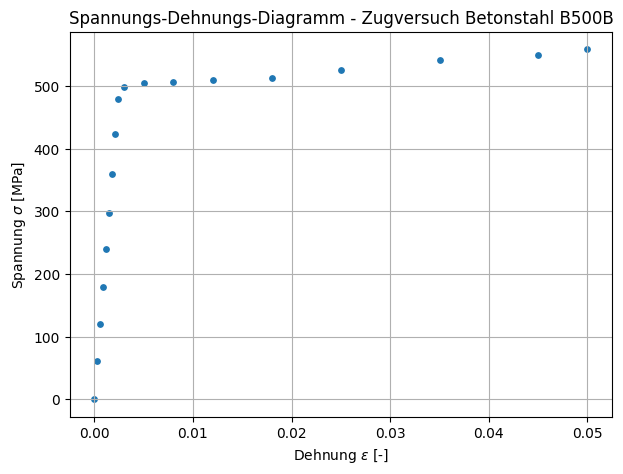

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(eps, sigma, s=15, color="tab:blue")
plt.xlabel(r"Dehnung $\varepsilon$ [-]")
plt.ylabel(r"Spannung $\sigma$ [MPa]")
plt.title("Spannungs-Dehnungs-Diagramm - Zugversuch Betonstahl B500B")
plt.grid(True)
plt.show()

### Aufgabe 3 — Gerade an den elastischen Bereich fitten
Der linear-elastische Bereich liegt etwa bei $\varepsilon \le 0{,}0025$.
1. Wähle diese Punkte mit einer **Maske** aus.
2. Passe mit `np.polyfit(..., 1)` eine **Gerade (Grad 1)** an diese Punkte an.
3. Die Steigung ist der E-Modul.

*Tipp:* `maske = eps <= 0.0025`; `koeff = np.polyfit(eps[maske], sigma[maske], 1)`.
`koeff[0]` ist die Steigung, `koeff[1]` der Achsenabschnitt.


In [4]:
maske = eps <= 0.0025
koeff = np.polyfit(eps[maske], sigma[maske], 1)
E_modul = koeff[0]

print(f"E-Modul (Steigung): {E_modul:.1f} MPa  =  {E_modul/1000:.1f} GPa")
print(f"Achsenabschnitt: {koeff[1]:.2f} MPa")

E-Modul (Steigung): 200238.9 MPa  =  200.2 GPa
Achsenabschnitt: -0.54 MPa


### Aufgabe 4 — Fit visualisieren
Zeichne die Messpunkte und die angepasste **Gerade** in ein Diagramm.

*Tipp:* `gerade = np.poly1d(koeff)` erzeugt eine Funktion; damit kannst du die Geraden-
werte berechnen, z. B. `gerade(eps_linie)` für `eps_linie = np.linspace(0, 0.0025, 50)`.


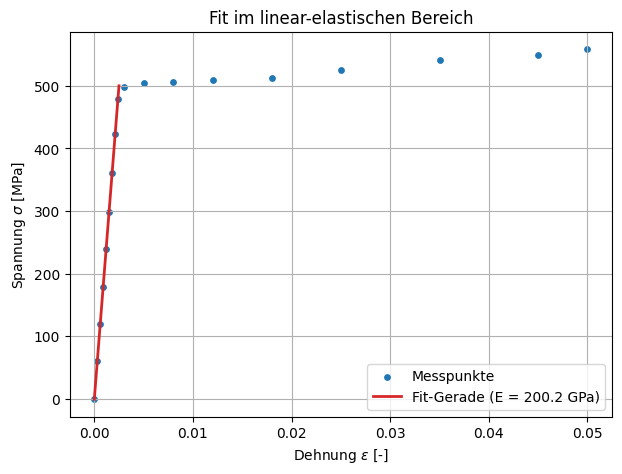

In [5]:
gerade   = np.poly1d(koeff)
eps_linie = np.linspace(0, 0.0025, 50)

plt.figure(figsize=(7, 5))
plt.scatter(eps, sigma, s=15, color="tab:blue", label="Messpunkte")
plt.plot(eps_linie, gerade(eps_linie), color="tab:red", lw=2, label=f"Fit-Gerade (E = {E_modul/1000:.1f} GPa)")
plt.xlabel(r"Dehnung $\varepsilon$ [-]")
plt.ylabel(r"Spannung $\sigma$ [MPa]")
plt.title("Fit im linear-elastischen Bereich")
plt.legend()
plt.grid(True)
plt.show()

### Aufgabe 5 — Beurteilung und Interpretation
1. Gib den E-Modul in **GPa** an (1 GPa = 1000 MPa).
2. Um welchen Werkstoff handelt es sich? (Vergleiche mit typischen Werten:
   Stahl ≈ 210 GPa, Beton ≈ 30 GPa, Aluminium ≈ 70 GPa.)
3. Lies aus dem Diagramm die **Streckgrenze** $f_y$ ab (Beginn des Plateaus).
   Welche Stahlsorte ist das vermutlich?
4. Berechne das Bestimmtheitsmaß $R^2$ für den Geraden-Fit.

$$ R^2 = 1 - \dfrac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$


In [6]:
E_GPa = E_modul / 1000
print(f"E-Modul: {E_GPa:.1f} GPa")

residuen = sigma[maske] - gerade(eps[maske])
ss_res   = np.sum(residuen**2)
ss_tot   = np.sum((sigma[maske] - np.mean(sigma[maske]))**2)
r2       = 1 - ss_res / ss_tot
print(f"R^2 (elastischer Bereich): {r2:.5f}")

E-Modul: 200.2 GPa
R^2 (elastischer Bereich): 0.99990


#### Lösungsvorschlag

1. **E-Modul:** $E \approx 200~\text{GPa}$ (siehe Ausgabe oben).
2. Der Wert liegt nahe an den typischen $210~\text{GPa}$ für **Stahl** – deutlich höher als Beton ($\approx 30~\text{GPa}$) oder Aluminium ($\approx 70~\text{GPa}$).
3. Die Messkurve verlässt die Gerade bei $\sigma \approx 500~\text{MPa}$ und geht in ein Plateau über $\Rightarrow$ Streckgrenze $f_y \approx 500~\text{MPa}$. Das passt genau zur bereits im Titel genannten Stahlsorte **B500B** (Betonstahl mit charakteristischer Streckgrenze von 500 MPa).
4. $R^2 \approx 0{,}9999$ (siehe Ausgabe oben) $\Rightarrow$ die Gerade beschreibt den elastischen Bereich hervorragend.

### Bonus (freiwillig)
- Passe mit `np.polyfit(eps, sigma, 4)` ein **Polynom 4. Grades** an die *gesamte* Kurve an
  und zeichne es über die Messpunkte. Beschreibt es die Form gut? Was passiert bei
  Extrapolation über den Messbereich hinaus?
- Welche Dehnung gehört nach dem Hookeschen Gesetz zu einer Spannung von 300 MPa?


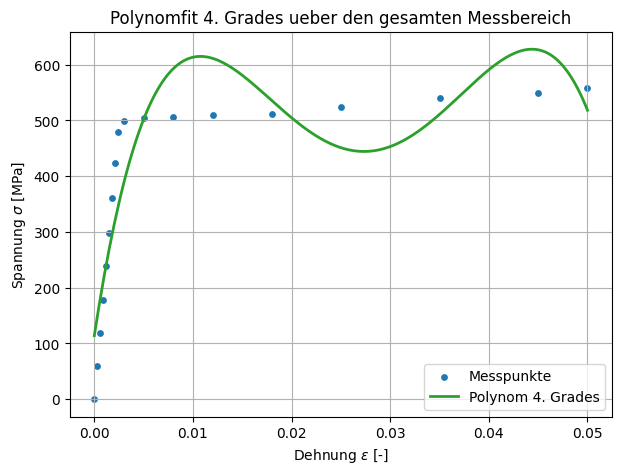

Dehnung bei 300 MPa (Hookesches Gesetz): 0.00150


In [7]:
# Polynom 4. Grades ueber die gesamte Kurve
koeff4 = np.polyfit(eps, sigma, 4)
poly4  = np.poly1d(koeff4)
eps_fein = np.linspace(eps.min(), eps.max(), 200)

plt.figure(figsize=(7, 5))
plt.scatter(eps, sigma, s=15, color="tab:blue", label="Messpunkte")
plt.plot(eps_fein, poly4(eps_fein), color="tab:green", lw=2, label="Polynom 4. Grades")
plt.xlabel(r"Dehnung $\varepsilon$ [-]")
plt.ylabel(r"Spannung $\sigma$ [MPa]")
plt.title("Polynomfit 4. Grades ueber den gesamten Messbereich")
plt.legend()
plt.grid(True)
plt.show()

# Dehnung bei 300 MPa nach dem Hookeschen Gesetz (im elastischen Bereich)
eps_300 = 300 / E_modul
print(f"Dehnung bei 300 MPa (Hookesches Gesetz): {eps_300:.5f}")

**Lösungsvorschlag Bonus:** Das Polynom 4. Grades beschreibt die gemessene Kurve im Bereich der Messpunkte gut, ist aber rein empirisch (kein physikalisches Modell). Bei **Extrapolation** über den Messbereich hinaus liefert es unrealistische Werte (z. B. abfallende oder stark ansteigende Spannungen), da es nicht auf realem Werkstoffverhalten basiert. Nach dem Hookeschen Gesetz gehört zu $\sigma = 300~\text{MPa}$ die Dehnung $\varepsilon = \sigma / E$ (siehe Ausgabe oben).